# SAR-Assisted Land-Cover Understanding under Degraded Optical Conditions

**Case study:** investigate whether Sentinel-1 SAR provides useful information when Sentinel-2
optical observations are partially unavailable (cloud-obscured).

## Problem formulation

Multi-label land-cover classification on paired Sentinel-1/Sentinel-2 patches from
**BigEarthNet v2.0 (reBEN)**, under three conditions (A: clean optical, B: degraded optical,
C: degraded optical + SAR) at six simulated cloud-coverage levels.

### Experiment matrix — 4 architectures × 3 fusion variants

| Variant | Input | Description |
|---|---|---|
| **B** | masked S2 (12ch) | optical-only, trained with mask augmentation |
| **C** | masked S2 ⊕ S1 (14ch) | **early fusion** — SAR concatenated as input channels |
| **D** | masked S2 ⊕ S1 | **late fusion** — separate encoders, features concatenated |

| Family | Encoder | Params (B variant) | Notes |
|---|---|---|---|
| **SimpleCNN** | 4 conv blocks (32→256) | ~1.9 M | baseline |
| **VGG11** | VGG-11-with-BN-style stacks (64→512) | ~9.5 M | deeper, no residuals |
| **ResNet18 (scratch)** | ResNet18-style residual encoder | ~11 M | depth + residuals, random init |
| **ResNet18 (pretrained)** | torchvision ResNet-18, ImageNet weights; first conv re-made for 12/14 bands (RGB weights averaged over channels), new 11-class head; LR 3·10⁻⁴ | ~11 M | tests whether *pretraining* fixes what capacity alone could not |

Plus **model A** (SimpleCNN on clean optical, no augmentation) as the required minimum baseline,
and **model H** (selective per-class fusion of the baseline family) exploiting class-conditional
SAR value. Deterministic per-patch evaluation masks make every comparison paired; a vectorised
**paired bootstrap** gives 95% CIs for every model at every level; **seed replicates** (3 seeds,
baseline family) bound training-stochasticity noise.

## Dataset (external resources — documented per instructions)

- [`hackelle/BigEarthNetV2-Lithuania-Summer-LMDB`](https://huggingface.co/datasets/hackelle/BigEarthNetV2-Lithuania-Summer-LMDB) —
  LMDB conversion of the official **BigEarthNet v2.0 (reBEN)** subset (Lithuania, summer),
  published by a member of the original BigEarthNet team (TU Berlin RSiM). 8,775 paired S1/S2
  patches (~2.5 GB), official train/validation/test splits, 19-class label set.
- Original dataset: Clasen et al., *"reBEN: Refined BigEarthNet Dataset for Remote Sensing Image Analysis"*, 2024.
- Pretrained weights: torchvision `ResNet18_Weights.IMAGENET1K_V1` (ImageNet-1k).
- Libraries: PyTorch, torchvision, numpy, pandas, scikit-learn, scipy, matplotlib, lmdb, safetensors, huggingface_hub.

**Known limitations of this subset (discussed at the end):** single country and season →
reduced class diversity; scene-level noisy CORINE labels; simulated masks approximate real clouds.


## 1. Setup


In [1]:
import json, math, random, time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
from scipy import ndimage
from sklearn.metrics import f1_score, average_precision_score
from tqdm.auto import tqdm

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', DEVICE, '|', torch.cuda.get_device_name(0) if DEVICE.type == 'cuda' else 'CPU')

DATA_DIR = Path('data/BENv2_lithuania_summer')
PROC_DIR = Path('data/processed'); PROC_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR  = Path('figures');        FIG_DIR.mkdir(exist_ok=True)

PATCH = 120
S2_BANDS = ['B01','B02','B03','B04','B05','B06','B07','B08','B8A','B09','B11','B12']
S1_BANDS = ['VV','VH']

MASK_LEVELS = [0.0, 0.25, 0.5, 0.75, 0.9, 1.0]

EPOCHS, BATCH, LR, WD = 30, 64, 1e-3, 1e-4
LR_PRETRAINED = 3e-4              # single fixed choice for fine-tuning (not tuned)
FORCE_RETRAIN = False
N_BOOT = 1000


C:\Users\varun\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


device: cuda | NVIDIA GeForce RTX 4060 Laptop GPU


## 2. Data acquisition


In [2]:
from huggingface_hub import snapshot_download

snapshot_download(repo_id='hackelle/BigEarthNetV2-Lithuania-Summer-LMDB',
                  repo_type='dataset', local_dir=DATA_DIR)

LMDB_PATH = DATA_DIR / 'BENv2_lithuania_summer.lmdb'
META_PATH = DATA_DIR / 'metadata_lithuania_summer.parquet'
for p in [LMDB_PATH, META_PATH]:
    assert p.exists(), f'missing {p}'
print('download OK:', sum(f.stat().st_size for f in DATA_DIR.rglob("*") if f.is_file()) / 1e9, 'GB')


Fetching 5 files:   0%|          | 0/5 [00:00<?, ?it/s]

Fetching 5 files: 100%|██████████| 5/5 [00:00<00:00, 193.08it/s]

download OK: 2.482130577 GB


## 3. Data inspection & cleaning

Patches flagged `contains_cloud_or_shadow` / `contains_seasonal_snow` would confound our
*controlled* degradation experiment — we check and drop them (this subset ships with zero).


(8775, 8)
['patch_id', 'labels', 'split', 'country', 's1_name', 's2v1_name', 'contains_seasonal_snow', 'contains_cloud_or_shadow']


,patch_id,labels,split,country,s1_name,s2v1_name,contains_seasonal_snow,contains_cloud_or_shadow
39329,S2A_MSIL2A_20170720T100031_N9999_R122_T34UDG_6...,[Marine waters],test,Lithuania,S1B_IW_GRDH_1SDV_20170719T045054_34UDG_61_54,S2A_MSIL2A_20170720T100031_61_54,False,False
39330,S2A_MSIL2A_20170720T100031_N9999_R122_T34UDG_6...,[Marine waters],test,Lithuania,S1B_IW_GRDH_1SDV_20170719T045054_34UDG_61_55,S2A_MSIL2A_20170720T100031_61_55,False,False
39331,S2A_MSIL2A_20170720T100031_N9999_R122_T34UDG_6...,[Marine waters],test,Lithuania,S1B_IW_GRDH_1SDV_20170719T045054_34UDG_61_56,S2A_MSIL2A_20170720T100031_61_56,False,False



split counts:
split
train         4206
validation    2418
test          2151
Name: count, dtype: int64

naturally cloudy patches: 0 | snowy: 0


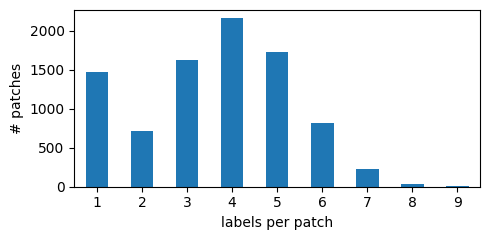

labels
Complex cultivation patterns                                                              4449
Mixed forest                                                                              4174
Coniferous forest                                                                         3862
Arable land                                                                               3738
Land principally occupied by agriculture, with significant areas of natural vegetation    3372
Pastures                                                                                  2981
Transitional woodland, shrub                                                              2588
Broad-leaved forest                                                                       1923
Marine waters                                                                             1432
Urban fabric                                                                              1270
Inland waters                              

In [3]:
meta = pd.read_parquet(META_PATH)
print(meta.shape); print(meta.columns.tolist())
display(meta.head(3))

print('\nsplit counts:'); print(meta['split'].value_counts())
print('\nnaturally cloudy patches:', int(meta['contains_cloud_or_shadow'].sum()),
      '| snowy:', int(meta['contains_seasonal_snow'].sum()))
meta = meta[~meta['contains_cloud_or_shadow'] & ~meta['contains_seasonal_snow']].reset_index(drop=True)

meta['n_labels'] = meta['labels'].apply(len)
ax = meta['n_labels'].value_counts().sort_index().plot.bar(figsize=(5,2.5), rot=0)
ax.set_xlabel('labels per patch'); ax.set_ylabel('# patches'); plt.tight_layout(); plt.show()

freq = meta.explode('labels')['labels'].value_counts()
print(freq.to_string())


### Label space — multi-label over the 11 classes with ≥ 1,000 positives


In [4]:
CLASSES = [
    'Urban fabric',
    'Arable land',
    'Pastures',
    'Complex cultivation patterns',
    'Land principally occupied by agriculture, with significant areas of natural vegetation',
    'Broad-leaved forest',
    'Coniferous forest',
    'Mixed forest',
    'Transitional woodland, shrub',
    'Inland waters',
    'Marine waters',
]
NC = len(CLASSES)
assert set(CLASSES) == set(freq[freq >= 1000].index), 'class list out of sync with data'

def to_multihot(labels):
    v = np.zeros(NC, dtype=np.float32)
    for l in labels:
        if l in CLASSES: v[CLASSES.index(l)] = 1.0
    return v

meta['y'] = meta['labels'].apply(to_multihot)
kept = meta['y'].apply(lambda v: v.sum() > 0)
print(f'dropping {int((~kept).sum())} patches with no positive label among the {NC} classes')
meta = meta[kept].reset_index(drop=True)

Y = np.stack(meta['y'])
tab = pd.DataFrame({s: Y[(meta['split'] == s).values].sum(0).astype(int)
                    for s in ['train', 'validation', 'test']}, index=CLASSES)
display(tab)
assert (tab > 20).all().all(), 'a class has too little support in some split'


dropping 1 patches with no positive label among the 11 classes


,train,validation,test
Urban fabric,620,385,265
Arable land,1714,1141,883
Pastures,1169,896,916
Complex cultivation patterns,1955,1322,1172
"Land principally occupied by agriculture, with significant areas of natural vegetation",1474,902,996
Broad-leaved forest,905,507,511
Coniferous forest,1782,887,1193
Mixed forest,1851,1109,1214
"Transitional woodland, shrub",1118,585,885
Inland waters,493,265,379


### Probing the LMDB — verify shapes, dtypes, value ranges


In [5]:
import lmdb
from safetensors.numpy import load as st_load

env = lmdb.open(str(LMDB_PATH), readonly=True, lock=False, readahead=True, subdir=LMDB_PATH.is_dir())

with env.begin() as txn:
    row = meta.iloc[0]
    s2 = st_load(bytes(txn.get(row['patch_id'].encode())))
    s1 = st_load(bytes(txn.get(row['s1_name'].encode())))

for k in sorted(s2): print(f'S2 {k}: {s2[k].shape} {s2[k].dtype}  range [{s2[k].min()}, {s2[k].max()}]')
for k in sorted(s1): print(f'S1 {k}: {s1[k].shape} {s1[k].dtype}  range [{s1[k].min():.2f}, {s1[k].max():.2f}]')


S2 B01: (20, 20) uint16  range [255, 281]
S2 B02: (120, 120) uint16  range [171, 296]
S2 B03: (120, 120) uint16  range [210, 311]
S2 B04: (120, 120) uint16  range [94, 182]
S2 B05: (60, 60) uint16  range [87, 151]
S2 B06: (60, 60) uint16  range [57, 113]
S2 B07: (60, 60) uint16  range [49, 109]
S2 B08: (120, 120) uint16  range [45, 125]
S2 B09: (20, 20) uint16  range [40, 82]
S2 B11: (60, 60) uint16  range [27, 67]
S2 B12: (60, 60) uint16  range [14, 63]
S2 B8A: (60, 60) uint16  range [36, 98]
S1 VH: (120, 120) float32  range [-43.09, -20.47]
S1 VV: (120, 120) float32  range [-28.59, -11.23]


## 4. Preprocessing → memory-mapped arrays

One pass over the LMDB: upsample every band bilinearly to the 10 m grid (120×120), store as
`float16` memmaps. Re-runs skip this entirely.


In [6]:
X_OPT_P, X_SAR_P, IDX_P = PROC_DIR/'X_opt.npy', PROC_DIR/'X_sar.npy', PROC_DIR/'index.parquet'

def resample_to_patch(arr):
    t = torch.from_numpy(arr.astype(np.float32))[None, None]
    if t.shape[-1] != PATCH:
        t = F.interpolate(t, size=(PATCH, PATCH), mode='bilinear', align_corners=False)
    return t[0, 0].numpy()

if not (X_OPT_P.exists() and X_SAR_P.exists() and IDX_P.exists()):
    N = len(meta)
    X_opt = np.lib.format.open_memmap(X_OPT_P, mode='w+', dtype=np.float16, shape=(N, 12, PATCH, PATCH))
    X_sar = np.lib.format.open_memmap(X_SAR_P, mode='w+', dtype=np.float16, shape=(N, 2, PATCH, PATCH))
    with env.begin() as txn:
        for i, row in enumerate(tqdm(meta.itertuples(), total=N, desc='LMDB -> memmap')):
            s2 = st_load(bytes(txn.get(row.patch_id.encode())))
            s1 = st_load(bytes(txn.get(row.s1_name.encode())))
            X_opt[i] = np.stack([resample_to_patch(s2[b]) for b in S2_BANDS]).astype(np.float16)
            X_sar[i] = np.stack([resample_to_patch(s1[b]) for b in S1_BANDS]).astype(np.float16)
    X_opt.flush(); X_sar.flush()
    meta.drop(columns=['y']).to_parquet(IDX_P)

X_opt = np.load(X_OPT_P, mmap_mode='r')
X_sar = np.load(X_SAR_P, mmap_mode='r')
idx_df = pd.read_parquet(IDX_P)
assert len(idx_df) == len(meta) and (idx_df['patch_id'].values == meta['patch_id'].values).all(), \
    'processed cache out of sync with metadata filter — delete data/processed and re-run'
print('X_opt', X_opt.shape, X_opt.dtype, '| X_sar', X_sar.shape, X_sar.dtype)

split_idx = {s: np.where((meta['split'] == s).values)[0] for s in ['train', 'validation', 'test']}
Y = np.stack(meta['y']).astype(np.float32)
print({k: len(v) for k, v in split_idx.items()})


X_opt (8774, 12, 120, 120) float16 | X_sar (8774, 2, 120, 120) float16
{'train': 4205, 'validation': 2418, 'test': 2151}


### Normalisation statistics (train split only — no leakage)

Masked pixels are set to 0 **after** standardisation (= per-band mean, the least-informative value).


In [7]:
STATS_P = PROC_DIR / 'norm_stats.json'
if not STATS_P.exists():
    tr = split_idx['train']
    sample = tr[::3]
    xo = X_opt[sample].astype(np.float32)
    xs = X_sar[sample].astype(np.float32)
    stats = {'opt_mean': xo.mean(axis=(0, 2, 3)).tolist(), 'opt_std': xo.std(axis=(0, 2, 3)).tolist(),
             'sar_mean': xs.mean(axis=(0, 2, 3)).tolist(), 'sar_std': xs.std(axis=(0, 2, 3)).tolist()}
    STATS_P.write_text(json.dumps(stats, indent=2)); del xo, xs
stats = json.loads(STATS_P.read_text())
OPT_MEAN = torch.tensor(stats['opt_mean']).view(1, 12, 1, 1)
OPT_STD  = torch.tensor(stats['opt_std']).view(1, 12, 1, 1)
SAR_MEAN = torch.tensor(stats['sar_mean']).view(1, 2, 1, 1)
SAR_STD  = torch.tensor(stats['sar_std']).view(1, 2, 1, 1)
pd.DataFrame({'band': S2_BANDS + S1_BANDS,
              'mean': stats['opt_mean'] + stats['sar_mean'],
              'std':  stats['opt_std'] + stats['sar_std']}).round(1)


,band,mean,std
0,B01,232.3,140.9
1,B02,306.5,192.0
2,B03,479.9,254.2
3,B04,372.7,330.9
4,B05,732.2,435.9
5,B06,1755.1,996.2
6,B07,2107.8,1214.4
7,B08,2268.5,1351.3
8,B8A,2304.7,1331.2
9,B09,2302.4,1290.1


### Visual sanity check — RGB composites and SAR


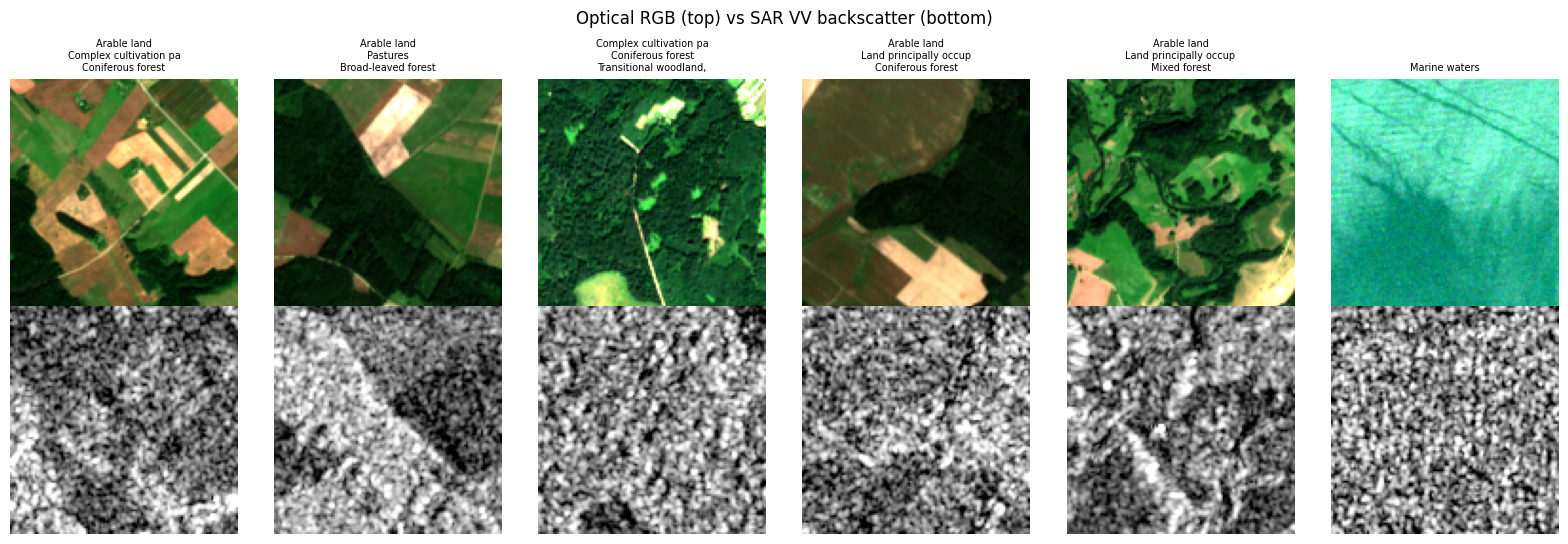

In [8]:
def rgb(i):
    x = X_opt[i, [3, 2, 1]].astype(np.float32)
    lo, hi = np.percentile(x, 2), np.percentile(x, 98)
    return np.clip((x - lo) / (hi - lo + 1e-6), 0, 1).transpose(1, 2, 0)

def sar_img(i, ch=0):
    x = X_sar[i, ch].astype(np.float32)
    lo, hi = np.percentile(x, 2), np.percentile(x, 98)
    return np.clip((x - lo) / (hi - lo + 1e-6), 0, 1)

rng = np.random.default_rng(SEED)
show = rng.choice(split_idx['train'], 6, replace=False)
fig, axes = plt.subplots(2, 6, figsize=(16, 5.5))
for j, i in enumerate(show):
    axes[0, j].imshow(rgb(i)); axes[1, j].imshow(sar_img(i), cmap='gray')
    labs = [c for c, v in zip(CLASSES, Y[i]) if v]
    axes[0, j].set_title('\n'.join(l[:22] for l in labs[:3]), fontsize=7)
    for ax in axes[:, j]: ax.axis('off')
plt.suptitle('Optical RGB (top) vs SAR VV backscatter (bottom)'); plt.tight_layout()
plt.savefig(FIG_DIR / 'samples.png', dpi=120); plt.show()


## 5. Simulated cloud masking

Blobby masks from thresholded smoothed Gaussian noise, exact coverage control.
**Evaluation masks are deterministic** per `(SEED, level, patch)` → paired comparisons.
**Training masks are random** (50% clean, else coverage ~ U(0.1, 0.95)).


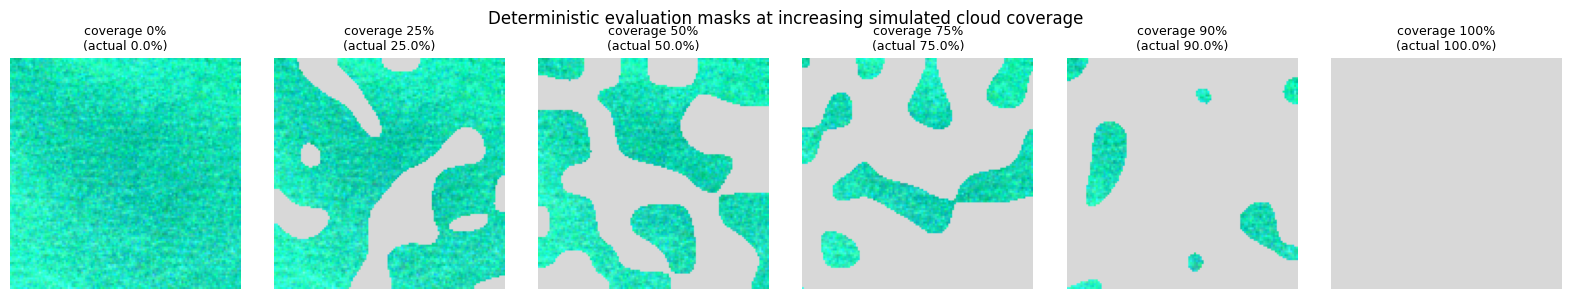

In [9]:
def cloud_mask(coverage, rng, size=PATCH, cells=8):
    if coverage <= 0: return np.zeros((size, size), bool)
    if coverage >= 1: return np.ones((size, size), bool)
    noise = ndimage.zoom(rng.standard_normal((cells, cells)), size / cells, order=3)
    return noise >= np.quantile(noise, 1 - coverage)

def eval_mask(level_i, patch_i):
    return cloud_mask(MASK_LEVELS[level_i], np.random.default_rng((SEED, level_i, int(patch_i))))

i = split_idx['test'][0]
fig, axes = plt.subplots(1, len(MASK_LEVELS), figsize=(16, 3))
for li, ax in enumerate(axes):
    m = eval_mask(li, i)
    im = rgb(i).copy(); im[m] = 0.85
    ax.imshow(im); ax.set_title(f'coverage {MASK_LEVELS[li]:.0%}\n(actual {m.mean():.1%})', fontsize=9)
    ax.axis('off')
plt.suptitle('Deterministic evaluation masks at increasing simulated cloud coverage')
plt.tight_layout(); plt.savefig(FIG_DIR / 'masks.png', dpi=120); plt.show()


## 6. Batching & degradation pipeline

All fusion models receive one 14-channel tensor; dual-encoder models split it internally.


In [10]:
def make_batch(ids, mask_spec, use_sar, train_rng=None):
    """mask_spec: None=clean | int=eval level index (deterministic) | 'random'=train augmentation."""
    xo = torch.from_numpy(X_opt[ids].astype(np.float32))
    xo = (xo - OPT_MEAN) / OPT_STD
    if mask_spec is not None:
        for j, pi in enumerate(ids):
            if mask_spec == 'random':
                if train_rng.random() < 0.5:
                    continue
                m = cloud_mask(train_rng.uniform(0.1, 0.95), train_rng)
            else:
                m = eval_mask(mask_spec, pi)
            xo[j, :, torch.from_numpy(m)] = 0.0
    if use_sar:
        xs = torch.from_numpy(X_sar[ids].astype(np.float32))
        xs = (xs - SAR_MEAN) / SAR_STD
        xo = torch.cat([xo, xs], 1)                     # SAR is never masked
    return xo

def batches(ids, bs, shuffle=False, rng=None):
    ids = ids.copy()
    if shuffle: rng.shuffle(ids)
    for k in range(0, len(ids), bs):
        yield ids[k:k + bs]


## 7. Model zoo — four architecture families

Late-fusion (D) variants pair the family's optical encoder with a lightweight SAR encoder
(2-channel SimpleCNN trunk, 256-d), except the scratch-ResNet family which keeps its original
half-width residual SAR encoder (existing checkpoint). The pretrained family adapts torchvision
ResNet-18: the 7×7 RGB stem conv is replaced by a 12/14-channel conv initialised with the
channel-averaged ImageNet weights (rescaled to preserve activation magnitude), plus a new
11-class head.


In [11]:
class SimpleCNN(nn.Module):
    def __init__(self, in_ch, n_classes=NC):
        super().__init__()
        layers, c = [], in_ch
        for out in [32, 64, 128, 256]:
            layers += [nn.Conv2d(c, out, 3, padding=1), nn.BatchNorm2d(out), nn.ReLU(inplace=True),
                       nn.Conv2d(out, out, 3, padding=1), nn.BatchNorm2d(out), nn.ReLU(inplace=True),
                       nn.MaxPool2d(2)]
            c = out
        self.features = nn.Sequential(*layers)
        self.head = nn.Sequential(nn.AdaptiveAvgPool2d(1), nn.Flatten(), nn.Dropout(0.3), nn.Linear(c, n_classes))
    def forward(self, x): return self.head(self.features(x))


class VGGNet(nn.Module):
    """VGG-11-with-BN flavour: plain conv stacks, no residuals."""
    def __init__(self, in_ch, n_classes=NC):
        super().__init__()
        cfg = [(64, 1), (128, 1), (256, 2), (512, 2), (512, 2)]
        layers, c = [], in_ch
        for cout, n in cfg:
            for k in range(n):
                layers += [nn.Conv2d(c if k == 0 else cout, cout, 3, padding=1),
                           nn.BatchNorm2d(cout), nn.ReLU(inplace=True)]
            layers += [nn.MaxPool2d(2)]
            c = cout
        self.features = nn.Sequential(*layers)
        self.head = nn.Sequential(nn.AdaptiveAvgPool2d(1), nn.Flatten(), nn.Dropout(0.3), nn.Linear(c, n_classes))
    def forward(self, x): return self.head(self.features(x))


class BasicBlock(nn.Module):
    def __init__(self, cin, cout, stride=1):
        super().__init__()
        self.conv1 = nn.Conv2d(cin, cout, 3, stride, 1, bias=False); self.bn1 = nn.BatchNorm2d(cout)
        self.conv2 = nn.Conv2d(cout, cout, 3, 1, 1, bias=False);     self.bn2 = nn.BatchNorm2d(cout)
        self.short = (nn.Sequential(nn.Conv2d(cin, cout, 1, stride, bias=False), nn.BatchNorm2d(cout))
                      if (stride != 1 or cin != cout) else nn.Identity())
    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        return F.relu(out + self.short(x))


class ResNetEncoder(nn.Module):
    def __init__(self, in_ch, width=64):
        super().__init__()
        w = [width, width * 2, width * 4, width * 8]
        self.stem = nn.Sequential(nn.Conv2d(in_ch, w[0], 3, 2, 1, bias=False), nn.BatchNorm2d(w[0]),
                                  nn.ReLU(inplace=True), nn.MaxPool2d(2))
        stages, c = [], w[0]
        for i, cout in enumerate(w):
            stages += [BasicBlock(c, cout, stride=1 if i == 0 else 2), BasicBlock(cout, cout)]
            c = cout
        self.stages = nn.Sequential(*stages)
        self.out_dim = c
    def forward(self, x): return self.stages(self.stem(x))


class ResNetNet(nn.Module):
    def __init__(self, in_ch, n_classes=NC):
        super().__init__()
        self.enc = ResNetEncoder(in_ch, width=64)
        self.head = nn.Sequential(nn.AdaptiveAvgPool2d(1), nn.Flatten(), nn.Dropout(0.3),
                                  nn.Linear(self.enc.out_dim, n_classes))
    def forward(self, x): return self.head(self.enc(x))


class DualEncoderCNN(nn.Module):
    """SimpleCNN late fusion (D of the baseline family)."""
    def __init__(self, n_classes=NC):
        super().__init__()
        self.opt_enc = SimpleCNN(12).features
        self.sar_enc = SimpleCNN(2).features
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.head = nn.Sequential(nn.Flatten(), nn.Dropout(0.3), nn.Linear(256 + 256, n_classes))
    def forward(self, x):
        f = torch.cat([self.pool(self.opt_enc(x[:, :12])), self.pool(self.sar_enc(x[:, 12:]))], 1)
        return self.head(f)


class DeepDualEncoder(nn.Module):
    """Scratch-ResNet late fusion (kept identical to the earlier model E checkpoint)."""
    def __init__(self, n_classes=NC):
        super().__init__()
        self.opt_enc = ResNetEncoder(12, width=64)
        self.sar_enc = ResNetEncoder(2, width=32)
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.head = nn.Sequential(nn.Flatten(), nn.Dropout(0.3),
                                  nn.Linear(self.opt_enc.out_dim + self.sar_enc.out_dim, n_classes))
    def forward(self, x):
        f = torch.cat([self.pool(self.opt_enc(x[:, :12])), self.pool(self.sar_enc(x[:, 12:]))], 1)
        return self.head(f)


class VGGLateFusion(nn.Module):
    def __init__(self, n_classes=NC):
        super().__init__()
        self.opt_enc = VGGNet(12).features
        self.sar_enc = SimpleCNN(2).features
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.head = nn.Sequential(nn.Flatten(), nn.Dropout(0.3), nn.Linear(512 + 256, n_classes))
    def forward(self, x):
        f = torch.cat([self.pool(self.opt_enc(x[:, :12])), self.pool(self.sar_enc(x[:, 12:]))], 1)
        return self.head(f)


def pretrained_resnet18(in_ch, n_classes=NC):
    m = torchvision.models.resnet18(weights=torchvision.models.ResNet18_Weights.IMAGENET1K_V1)
    w = m.conv1.weight.data                                  # [64, 3, 7, 7]
    conv1 = nn.Conv2d(in_ch, 64, 7, 2, 3, bias=False)
    conv1.weight.data = w.mean(1, keepdim=True).repeat(1, in_ch, 1, 1) * (3.0 / in_ch)
    m.conv1 = conv1
    m.fc = nn.Linear(512, n_classes)
    return m


class PretResNetLateFusion(nn.Module):
    def __init__(self, n_classes=NC):
        super().__init__()
        self.opt_enc = nn.Sequential(*list(pretrained_resnet18(12).children())[:-1])  # -> [B,512,1,1]
        self.sar_enc = SimpleCNN(2).features
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.head = nn.Sequential(nn.Dropout(0.3), nn.Linear(512 + 256, n_classes))
    def forward(self, x):
        fo = torch.flatten(self.opt_enc(x[:, :12]), 1)
        fs = torch.flatten(self.pool(self.sar_enc(x[:, 12:])), 1)
        return self.head(torch.cat([fo, fs], 1))


for label, m in [('SimpleCNN(12)', SimpleCNN(12)), ('VGGNet(12)', VGGNet(12)),
                 ('ResNetNet(12)', ResNetNet(12)), ('pretrained_resnet18(12)', pretrained_resnet18(12)),
                 ('DualEncoderCNN', DualEncoderCNN()), ('VGGLateFusion', VGGLateFusion()),
                 ('DeepDualEncoder', DeepDualEncoder()), ('PretResNetLateFusion', PretResNetLateFusion())]:
    print(f'{label}: {sum(p.numel() for p in m.parameters()) / 1e6:.2f} M params')
del m


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to C:\Users\varun/.cache\torch\hub\checkpoints\resnet18-f37072fd.pth


  0%|          | 0.00/44.7M [00:00<?, ?B/s]

  0%|          | 128k/44.7M [00:04<24:03, 32.3kB/s]

  1%|          | 256k/44.7M [00:13<43:51, 17.7kB/s]

  1%|          | 384k/44.7M [00:18<37:17, 20.8kB/s]

...

 94%|█████████▍| 41.9M/44.7M [00:26<00:00, 8.96MB/s]

 96%|█████████▌| 42.9M/44.7M [00:26<00:00, 9.01MB/s]

 98%|█████████▊| 43.9M/44.7M [00:26<00:00, 9.28MB/s]

100%|██████████| 44.7M/44.7M [00:26<00:00, 1.74MB/s]

SimpleCNN(12): 1.18 M params
VGGNet(12): 9.24 M params
ResNetNet(12): 11.18 M params
pretrained_resnet18(12): 11.21 M params
DualEncoderCNN: 2.36 M params
VGGLateFusion: 10.41 M params
DeepDualEncoder: 13.98 M params
PretResNetLateFusion: 12.39 M params


## 8. Training — the full matrix

Identical regime for everything (AdamW, cosine schedule, class-balanced BCE, AMP, best-val
checkpointing); the pretrained family fine-tunes at LR 3·10⁻⁴ (one fixed choice, not tuned).
Completed models load from checkpoint (`FORCE_RETRAIN = True` to redo). Validation metric:
macro-F1 at 50% deterministic coverage (clean for model A).


In [12]:
pos = Y[split_idx['train']].mean(0)
POS_WEIGHT = torch.tensor(np.clip((1 - pos) / pos, 1.0, 10.0), dtype=torch.float32, device=DEVICE)

@torch.no_grad()
def predict(model, ids, mask_spec, use_sar, bs=256):
    model.eval(); out = []
    for b in batches(ids, bs):
        x = make_batch(b, mask_spec, use_sar).to(DEVICE, non_blocking=True)
        with torch.autocast('cuda', enabled=DEVICE.type == 'cuda'):
            out.append(torch.sigmoid(model(x)).float().cpu())
    return torch.cat(out).numpy()

def macro_f1(y, p, thr=0.5): return f1_score(y, p >= thr, average='macro', zero_division=0)

def train_or_load(name, model_fn, use_sar, mask_train, val_mask_spec, epochs=EPOCHS, seed=SEED, lr=LR):
    ckpt, hist_p = PROC_DIR / f'{name}.pt', PROC_DIR / f'{name}_history.csv'
    torch.manual_seed(seed); np.random.seed(seed)
    model = model_fn().to(DEVICE)
    if ckpt.exists() and not FORCE_RETRAIN:
        model.load_state_dict(torch.load(ckpt, map_location=DEVICE, weights_only=True))
        print(f'[{name}] loaded checkpoint')
        return model, (pd.read_csv(hist_p) if hist_p.exists() else None)
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=WD)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)
    scaler = torch.amp.GradScaler(enabled=DEVICE.type == 'cuda')
    crit = nn.BCEWithLogitsLoss(pos_weight=POS_WEIGHT)
    tr, va = split_idx['train'], split_idx['validation']
    rng = np.random.default_rng(seed)
    best_f1, best_state, hist = -1, None, []
    for ep in range(epochs):
        model.train(); losses = []; t0 = time.time()
        for b in batches(tr, BATCH, shuffle=True, rng=rng):
            x = make_batch(b, 'random' if mask_train else None, use_sar, train_rng=rng).to(DEVICE)
            yb = torch.from_numpy(Y[b]).to(DEVICE)
            opt.zero_grad(set_to_none=True)
            with torch.autocast('cuda', enabled=DEVICE.type == 'cuda'):
                loss = crit(model(x), yb)
            scaler.scale(loss).backward(); scaler.step(opt); scaler.update()
            losses.append(loss.item())
        sched.step()
        vf1 = macro_f1(Y[va], predict(model, va, val_mask_spec, use_sar))
        hist.append({'epoch': ep, 'loss': float(np.mean(losses)), 'val_macro_f1': vf1})
        if vf1 > best_f1: best_f1, best_state = vf1, {k: v.clone() for k, v in model.state_dict().items()}
        print(f'[{name}] ep {ep + 1:02d}/{epochs}  loss {np.mean(losses):.4f}  val mF1 {vf1:.4f}  ({time.time() - t0:.0f}s)')
    model.load_state_dict(best_state)
    pd.DataFrame(hist).to_csv(hist_p, index=False)
    torch.save(model.state_dict(), ckpt)
    print(f'[{name}] best val macro-F1 = {best_f1:.4f}')
    return model, pd.DataFrame(hist)

LEVEL50 = MASK_LEVELS.index(0.5)

# family -> variant -> (checkpoint name, constructor, use_sar)
# (names of previously trained models are kept so their checkpoints are reused)
FAMILIES = {
    'SimpleCNN': {
        'B': ('model_B_optical_maskaug',      lambda: SimpleCNN(12), False),
        'C': ('model_C_opticalSAR_maskaug',   lambda: SimpleCNN(14), True),
        'D': ('model_D_opticalSAR_latefusion', DualEncoderCNN,       True)},
    'VGG11': {
        'B': ('vgg_B_optical',      lambda: VGGNet(12), False),
        'C': ('vgg_C_earlyfusion',  lambda: VGGNet(14), True),
        'D': ('vgg_D_latefusion',   VGGLateFusion,      True)},
    'ResNet18-scratch': {
        'B': ('resnet_B_optical',       lambda: ResNetNet(12), False),
        'C': ('resnet_C_earlyfusion',   lambda: ResNetNet(14), True),
        'D': ('model_E_deep_latefusion', DeepDualEncoder,      True)},
    'ResNet18-pretrained': {
        'B': ('pret18_B_optical',     lambda: pretrained_resnet18(12), False),
        'C': ('pret18_C_earlyfusion', lambda: pretrained_resnet18(14), True),
        'D': ('pret18_D_latefusion',  PretResNetLateFusion,            True)},
}


In [13]:
model_A, _ = train_or_load('model_A_optical_clean', lambda: SimpleCNN(12),
                           use_sar=False, mask_train=False, val_mask_spec=None)


[model_A_optical_clean] loaded checkpoint


In [14]:
trained = {}
for fam, variants in FAMILIES.items():
    for var, (name, fn, use_sar) in variants.items():
        lr = LR_PRETRAINED if fam == 'ResNet18-pretrained' else LR
        m, _ = train_or_load(name, fn, use_sar=use_sar, mask_train=True,
                             val_mask_spec=LEVEL50, lr=lr)
        trained[(fam, var)] = (m, use_sar)

model_B = trained[('SimpleCNN', 'B')][0]   # baseline-family handles used by later sections
model_D = trained[('SimpleCNN', 'D')][0]


[model_B_optical_maskaug] loaded checkpoint
[model_C_opticalSAR_maskaug] loaded checkpoint


[model_D_opticalSAR_latefusion] loaded checkpoint


[vgg_B_optical] ep 01/30  loss 0.6991  val mF1 0.6451  (54s)


[vgg_B_optical] ep 02/30  loss 0.6354  val mF1 0.6567  (44s)


[vgg_B_optical] ep 03/30  loss 0.6080  val mF1 0.6847  (39s)


...

[pret18_D_latefusion] ep 27/30  loss 0.1032  val mF1 0.7160  (38s)


[pret18_D_latefusion] ep 28/30  loss 0.1047  val mF1 0.7154  (38s)


[pret18_D_latefusion] ep 29/30  loss 0.1060  val mF1 0.7168  (38s)


[pret18_D_latefusion] ep 30/30  loss 0.0987  val mF1 0.7176  (39s)


[pret18_D_latefusion] best val macro-F1 = 0.7236


### Training curves (one panel per family)


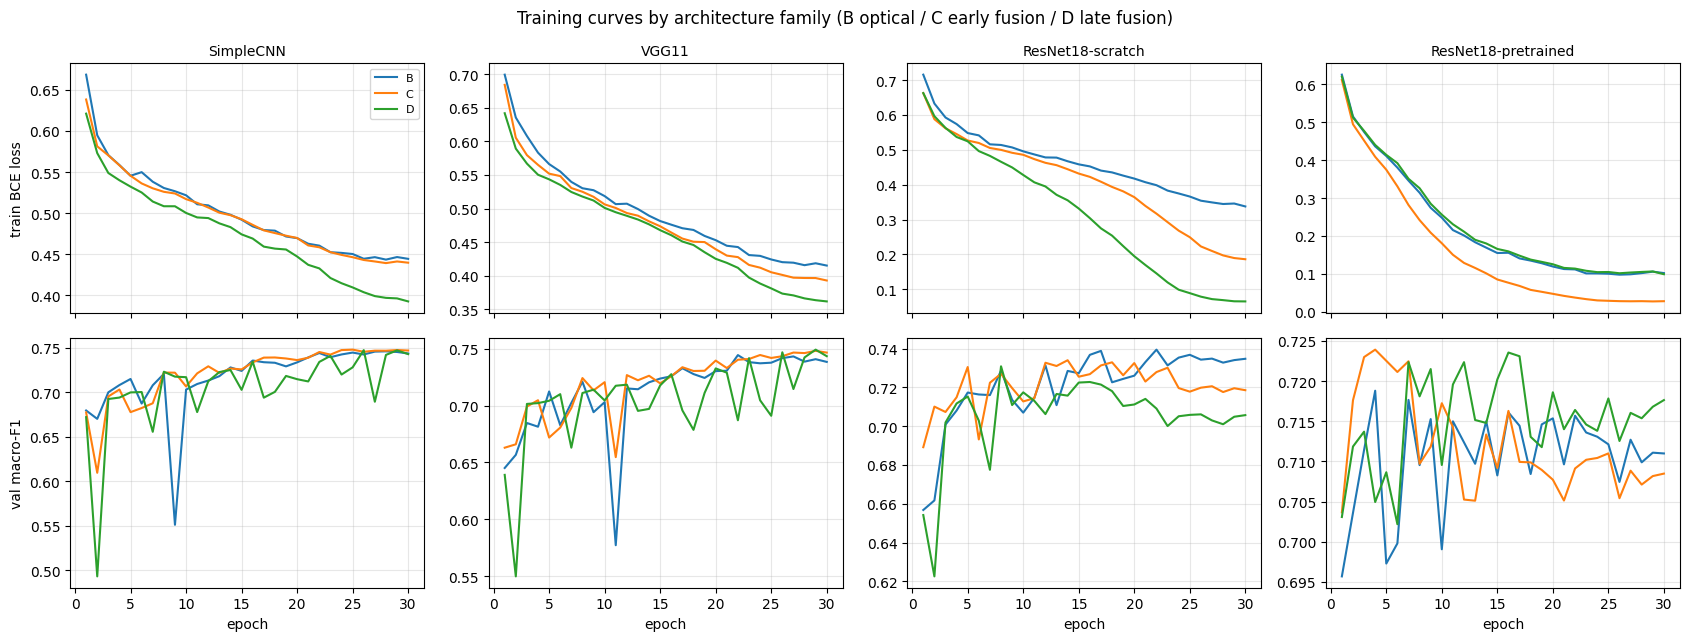

In [15]:
fig, axes = plt.subplots(2, 4, figsize=(17, 6.5), sharex=True)
for col, (fam, variants) in enumerate(FAMILIES.items()):
    for var, (name, _, _) in variants.items():
        p = PROC_DIR / f'{name}_history.csv'
        if not p.exists(): continue
        h = pd.read_csv(p)
        axes[0, col].plot(h['epoch'] + 1, h['loss'], label=var)
        axes[1, col].plot(h['epoch'] + 1, h['val_macro_f1'], label=var)
    axes[0, col].set_title(fam, fontsize=10); axes[0, col].grid(alpha=.3); axes[1, col].grid(alpha=.3)
    axes[1, col].set_xlabel('epoch')
axes[0, 0].set_ylabel('train BCE loss'); axes[1, 0].set_ylabel('val macro-F1'); axes[0, 0].legend(fontsize=8)
plt.suptitle('Training curves by architecture family (B optical / C early fusion / D late fusion)')
plt.tight_layout(); plt.savefig(FIG_DIR / 'training_curves.png', dpi=120); plt.show()


## 9. Evaluation — the full matrix × coverage levels

Metrics: **macro-F1** (primary), **mAP** (threshold-free), **label accuracy** (per-label binary
accuracy averaged over classes and patches — note its high base rate: predicting all-negative
already scores ≈ the negative prevalence) and **subset accuracy** (exact match, strictest).
Threshold fixed at 0.5 everywhere.


In [16]:
te = split_idx['test']
EVALS = [('A | SimpleCNN clean-trained', model_A, False)] + \
        [(f'{fam} | {var}', m, u) for (fam, var), (m, u) in trained.items()]
results, probs_cache = [], {}
for name, model, use_sar in EVALS:
    for li, lvl in enumerate(tqdm(MASK_LEVELS, desc=name)):
        p = predict(model, te, li if lvl > 0 else None, use_sar)
        probs_cache[(name, lvl)] = p
        pred = p >= 0.5
        results.append({'model': name, 'coverage': lvl,
                        'macro_F1': macro_f1(Y[te], p),
                        'mAP': average_precision_score(Y[te], p, average='macro'),
                        'label_acc': float((pred == Y[te].astype(bool)).mean()),
                        'subset_acc': float((pred == Y[te].astype(bool)).all(1).mean())})
res = pd.DataFrame(results)
for metric in ['macro_F1', 'label_acc', 'subset_acc']:
    print(f'\n=== {metric} ===')
    display(res.pivot(index='coverage', columns='model', values=metric).round(4))
res.to_csv(PROC_DIR / 'results.csv', index=False)


A | SimpleCNN clean-trained:   0%|          | 0/6 [00:00<?, ?it/s]

A | SimpleCNN clean-trained:  17%|█▋        | 1/6 [00:08<00:41,  8.31s/it]

A | SimpleCNN clean-trained:  33%|███▎      | 2/6 [00:20<00:43, 10.80s/it]

A | SimpleCNN clean-trained:  50%|█████     | 3/6 [00:32<00:34, 11.34s/it]

A | SimpleCNN clean-trained:  67%|██████▋   | 4/6 [00:44<00:23, 11.57s/it]

...

model,A | SimpleCNN clean-trained,ResNet18-pretrained | B,ResNet18-pretrained | C,ResNet18-pretrained | D,ResNet18-scratch | B,ResNet18-scratch | C,ResNet18-scratch | D,SimpleCNN | B,SimpleCNN | C,SimpleCNN | D,VGG11 | B,VGG11 | C,VGG11 | D
coverage,,,,,,,,,,,,,
0.00,0.7528,0.7295,0.7236,0.7173,0.7483,0.7354,0.7254,0.7495,0.7514,0.7507,0.7462,0.7519,0.7504
0.25,0.7049,0.7274,0.7216,0.7179,0.7464,0.7318,0.7260,0.7461,0.7485,0.7461,0.7457,0.7504,0.7498
0.50,0.6326,0.7180,0.7198,0.7174,0.7417,0.7280,0.7257,0.7465,0.7412,0.7443,0.7403,0.7472,0.7468
0.75,0.4116,0.7049,0.7117,0.7119,0.7223,0.7218,0.7215,0.7301,0.7333,0.7350,0.7295,0.7384,0.7407
0.90,0.2546,0.6761,0.7052,0.7019,0.6988,0.7134,0.7114,0.7144,0.7229,0.7225,0.7072,0.7277,0.7326
1.00,0.1179,0.0878,0.6441,0.6444,0.0000,0.7050,0.6010,0.3295,0.7111,0.6388,0.0000,0.7105,0.5507



=== label_acc ===


model,A | SimpleCNN clean-trained,ResNet18-pretrained | B,ResNet18-pretrained | C,ResNet18-pretrained | D,ResNet18-scratch | B,ResNet18-scratch | C,ResNet18-scratch | D,SimpleCNN | B,SimpleCNN | C,SimpleCNN | D,VGG11 | B,VGG11 | C,VGG11 | D
coverage,,,,,,,,,,,,,
0.00,0.8041,0.7861,0.7788,0.7883,0.7994,0.7838,0.7787,0.8003,0.8022,0.8023,0.7969,0.8038,0.8043
0.25,0.7440,0.7821,0.7738,0.7853,0.7963,0.7800,0.7761,0.7979,0.7990,0.8003,0.7945,0.8016,0.8043
0.50,0.6962,0.7756,0.7687,0.7774,0.7897,0.7748,0.7733,0.7954,0.7921,0.7990,0.7909,0.7977,0.8017
0.75,0.6567,0.7598,0.7572,0.7668,0.7740,0.7606,0.7624,0.7798,0.7831,0.7892,0.7782,0.7881,0.7960
0.90,0.6460,0.7283,0.7457,0.7498,0.7523,0.7453,0.7432,0.7668,0.7722,0.7812,0.7629,0.7766,0.7901
1.00,0.6333,0.5755,0.6947,0.7460,0.6395,0.7309,0.6759,0.5753,0.7618,0.7443,0.6395,0.7608,0.7416



=== subset_acc ===


model,A | SimpleCNN clean-trained,ResNet18-pretrained | B,ResNet18-pretrained | C,ResNet18-pretrained | D,ResNet18-scratch | B,ResNet18-scratch | C,ResNet18-scratch | D,SimpleCNN | B,SimpleCNN | C,SimpleCNN | D,VGG11 | B,VGG11 | C,VGG11 | D
coverage,,,,,,,,,,,,,
0.00,0.1371,0.1125,0.1013,0.1144,0.1265,0.1065,0.1116,0.1348,0.1311,0.1320,0.1339,0.1367,0.1423
0.25,0.0404,0.1097,0.1074,0.1158,0.1176,0.1051,0.1079,0.1320,0.1265,0.1297,0.1246,0.1344,0.1418
0.50,0.0386,0.0958,0.0953,0.1051,0.1139,0.0939,0.1069,0.1260,0.1227,0.1292,0.1181,0.1255,0.1362
0.75,0.0349,0.0869,0.0883,0.1013,0.1037,0.0879,0.1013,0.1111,0.1120,0.1185,0.1097,0.1153,0.1255
0.90,0.0339,0.0423,0.0921,0.0944,0.0953,0.0776,0.0846,0.0962,0.1069,0.1130,0.0972,0.1027,0.1162
1.00,0.0274,0.0000,0.0632,0.0851,0.0000,0.0711,0.0609,0.0014,0.0990,0.0967,0.0000,0.0967,0.0865


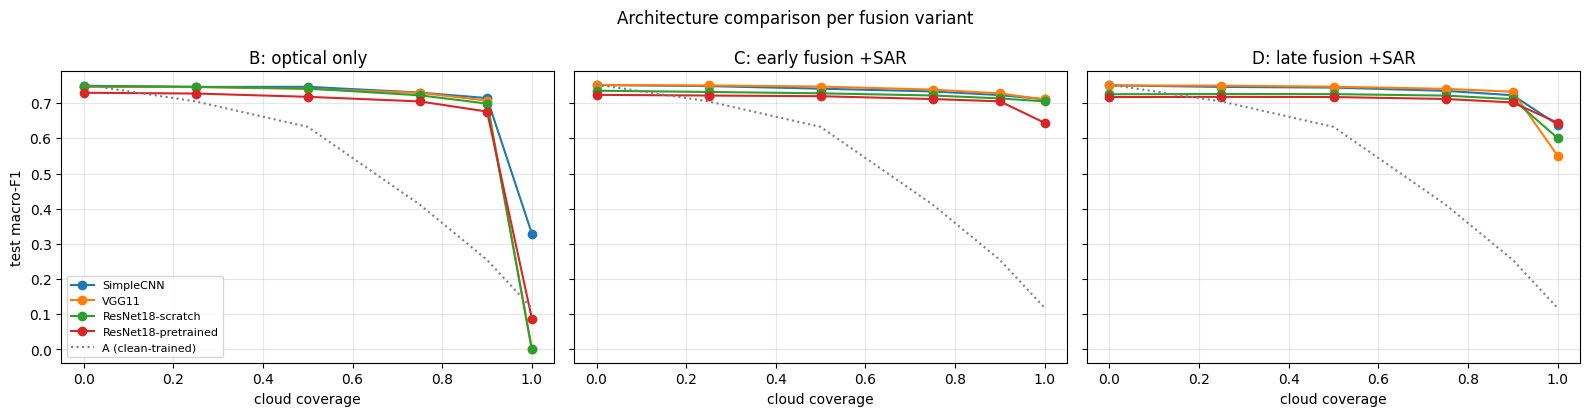

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.2), sharey=True)
for ax, var in zip(axes, ['B', 'C', 'D']):
    for fam in FAMILIES:
        g = res[res['model'] == f'{fam} | {var}']
        ax.plot(g['coverage'], g['macro_F1'], marker='o', label=fam)
    g = res[res['model'] == 'A | SimpleCNN clean-trained']
    ax.plot(g['coverage'], g['macro_F1'], ls=':', color='gray', label='A (clean-trained)')
    ax.set_title({'B': 'B: optical only', 'C': 'C: early fusion +SAR', 'D': 'D: late fusion +SAR'}[var])
    ax.set_xlabel('cloud coverage'); ax.grid(alpha=.3)
axes[0].set_ylabel('test macro-F1'); axes[0].legend(fontsize=8)
plt.suptitle('Architecture comparison per fusion variant')
plt.tight_layout(); plt.savefig(FIG_DIR / 'coverage_curves.png', dpi=120); plt.show()


### Paired bootstrap confidence intervals — all models, vectorised

1,000 shared resamples of the test set. Macro-F1 per resample is computed in closed form from
per-class TP/FP/FN counts (a single matrix product per model×level), so CIs for the whole
matrix cost seconds. Two questions: **(a)** does an architecture beat the SimpleCNN baseline
at the same variant? **(b)** within each family, does SAR (C or D) beat that family's B?


In [18]:
rng_b = np.random.default_rng(SEED)
boot_idx = rng_b.integers(0, len(te), size=(N_BOOT, len(te)))
W = np.zeros((N_BOOT, len(te)), dtype=np.float32)
for r in range(N_BOOT):
    np.add.at(W[r], boot_idx[r], 1.0)

YT = Y[te].astype(bool)

def boot_macro_f1(pred, cols=None):
    """pred: bool [N, NC] -> macro-F1 per bootstrap resample [N_BOOT]."""
    TP = W @ (pred & YT); FP = W @ (pred & ~YT); FN = W @ (~pred & YT)
    f1 = 2 * TP / np.maximum(2 * TP + FP + FN, 1e-9)
    return f1[:, cols].mean(1) if cols is not None else f1.mean(1)

boot = {(name, lvl): boot_macro_f1(probs_cache[(name, lvl)] >= 0.5)
        for name, _, _ in EVALS for lvl in MASK_LEVELS}

def delta_ci(a, b):
    d = boot[a] - boot[b]
    return d.mean(), np.percentile(d, 2.5), np.percentile(d, 97.5)

rows = []
for lvl in MASK_LEVELS:
    for fam in FAMILIES:
        if fam != 'SimpleCNN':                       # (a) architecture effect on optical-only
            m, lo, hi = delta_ci((f'{fam} | B', lvl), ('SimpleCNN | B', lvl))
            rows.append({'coverage': lvl, 'comparison': f'{fam} B vs SimpleCNN B',
                         'delta': m, 'lo': lo, 'hi': hi, 'significant': bool(lo > 0 or hi < 0)})
        for var in ['C', 'D']:                       # (b) SAR effect within family
            m, lo, hi = delta_ci((f'{fam} | {var}', lvl), (f'{fam} | B', lvl))
            rows.append({'coverage': lvl, 'comparison': f'{fam} {var} vs {fam} B',
                         'delta': m, 'lo': lo, 'hi': hi, 'significant': bool(lo > 0 or hi < 0)})
ci = pd.DataFrame(rows)
print('(a) architecture effect (optical-only B variants vs baseline):')
display(ci[ci['comparison'].str.contains('SimpleCNN B')].pivot(
    index='coverage', columns='comparison', values='delta').round(4))
print('(b) within-family SAR effect (significant cells only):')
display(ci[ci['significant'] & ~ci['comparison'].str.contains('SimpleCNN B')].round(4))
ci.to_csv(PROC_DIR / 'bootstrap_ci.csv', index=False)


(a) architecture effect (optical-only B variants vs baseline):


comparison,ResNet18-pretrained B vs SimpleCNN B,ResNet18-scratch B vs SimpleCNN B,SimpleCNN C vs SimpleCNN B,SimpleCNN D vs SimpleCNN B,VGG11 B vs SimpleCNN B
coverage,,,,,
0.00,-0.0202,-0.0014,0.0018,0.0011,-0.0035
0.25,-0.0188,0.0002,0.0023,0.0000,-0.0005
0.50,-0.0286,-0.0048,-0.0054,-0.0023,-0.0064
0.75,-0.0252,-0.0078,0.0034,0.0048,-0.0006
0.90,-0.0383,-0.0157,0.0084,0.0079,-0.0072
1.00,-0.2418,-0.3296,0.3815,0.3092,-0.3296


(b) within-family SAR effect (significant cells only):


,coverage,comparison,delta,lo,hi,significant
3,0.00,VGG11 C vs VGG11 B,0.0058,0.0003,0.0108,True
6,0.00,ResNet18-scratch C vs ResNet18-scratch B,-0.0127,-0.0193,-0.0066,True
7,0.00,ResNet18-scratch D vs ResNet18-scratch B,-0.0227,-0.0294,-0.0163,True
10,0.00,ResNet18-pretrained D vs ResNet18-pretrained B,-0.0120,-0.0198,-0.0045,True
17,0.25,ResNet18-scratch C vs ResNet18-scratch B,-0.0144,-0.0210,-0.0085,True
18,0.25,ResNet18-scratch D vs ResNet18-scratch B,-0.0202,-0.0266,-0.0142,True
21,0.25,ResNet18-pretrained D vs ResNet18-pretrained B,-0.0097,-0.0172,-0.0016,True
25,0.50,VGG11 C vs VGG11 B,0.0070,0.0015,0.0128,True
26,0.50,VGG11 D vs VGG11 B,0.0066,0.0010,0.0121,True
28,0.50,ResNet18-scratch C vs ResNet18-scratch B,-0.0137,-0.0200,-0.0079,True


### Seed replicates — training-stochasticity check (baseline family)

B, C, D of the SimpleCNN family retrained with seeds 43/44 (evaluation masks fixed): if the
paired SAR deltas keep their sign across all seeds, the effect is not training luck.


[model_B_optical_maskaug] loaded checkpoint


[model_C_opticalSAR_maskaug] loaded checkpoint


[model_D_opticalSAR_latefusion] loaded checkpoint


[model_B_optical_maskaug_seed43] loaded checkpoint


[model_C_opticalSAR_maskaug_seed43] loaded checkpoint


...

[model_B_optical_maskaug_seed44] loaded checkpoint


[model_C_opticalSAR_maskaug_seed44] loaded checkpoint


[model_D_opticalSAR_latefusion_seed44] loaded checkpoint


Per-seed paired deltas:


model        C-B                     D-B                
seed          42      43      44      42      43      44
coverage                                                
0.00      0.0018 -0.0016 -0.0044  0.0012 -0.0045 -0.0065
0.25      0.0024 -0.0033 -0.0034  0.0000 -0.0034 -0.0053
0.50     -0.0053 -0.0046 -0.0040 -0.0022 -0.0011 -0.0018
0.75      0.0032  0.0059  0.0012  0.0049  0.0075  0.0082
0.90      0.0085  0.0169  0.0122  0.0081  0.0119  0.0172
1.00      0.3816  0.5584  0.6332  0.3093  0.4770  0.5926

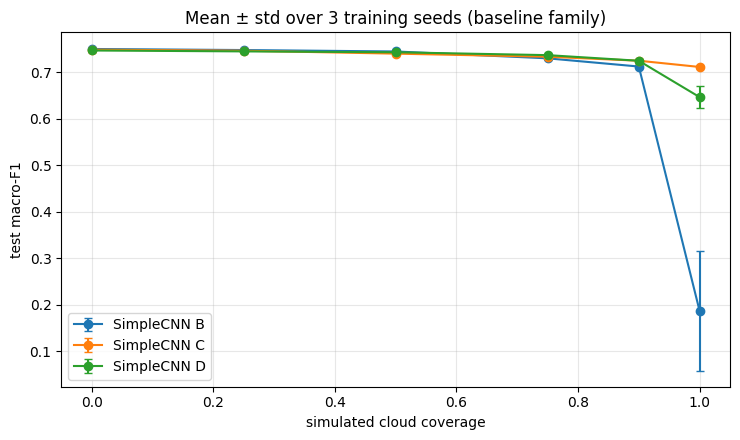

In [19]:
REPL_SPECS = [('B', 'model_B_optical_maskaug',       lambda: SimpleCNN(12), False),
              ('C', 'model_C_opticalSAR_maskaug',     lambda: SimpleCNN(14), True),
              ('D', 'model_D_opticalSAR_latefusion',  DualEncoderCNN,        True)]
SEEDS = [SEED, 43, 44]

rep_rows = []
for seed in SEEDS:
    for short, base, fn, use_sar in REPL_SPECS:
        name = base if seed == SEED else f'{base}_seed{seed}'
        model, _ = train_or_load(name, fn, use_sar=use_sar, mask_train=True,
                                 val_mask_spec=LEVEL50, seed=seed)
        for li, lvl in enumerate(MASK_LEVELS):
            p = predict(model, te, li if lvl > 0 else None, use_sar)
            rep_rows.append({'model': short, 'seed': seed, 'coverage': lvl,
                             'macro_F1': macro_f1(Y[te], p)})
        if seed != SEED: del model; torch.cuda.empty_cache()
rep = pd.DataFrame(rep_rows); rep.to_csv(PROC_DIR / 'seed_replicates.csv', index=False)

piv = rep.pivot_table(index=['coverage', 'seed'], columns='model', values='macro_F1')
piv['C-B'] = piv['C'] - piv['B']; piv['D-B'] = piv['D'] - piv['B']
print('Per-seed paired deltas:')
display(piv[['C-B', 'D-B']].round(4).unstack('seed'))

fig, ax = plt.subplots(figsize=(7.5, 4.5))
for m in ['B', 'C', 'D']:
    g = rep[rep['model'] == m].groupby('coverage')['macro_F1']
    ax.errorbar(g.mean().index, g.mean(), yerr=g.std(), marker='o', capsize=3, label=f'SimpleCNN {m}')
ax.set_xlabel('simulated cloud coverage'); ax.set_ylabel('test macro-F1')
ax.set_title('Mean ± std over 3 training seeds (baseline family)'); ax.legend(); ax.grid(alpha=.3)
plt.tight_layout(); plt.savefig(FIG_DIR / 'seed_replicates.png', dpi=120); plt.show()


### Class-conditional SAR value — physics says SAR should help some classes, not others

C-band SAR: **water** specular → very low backscatter; **urban** double-bounce → very high;
**vegetation types** → poorly separated. Grouping the 11 classes accordingly and testing the
per-group SAR effect (baseline family D vs B) with paired bootstrap CIs.


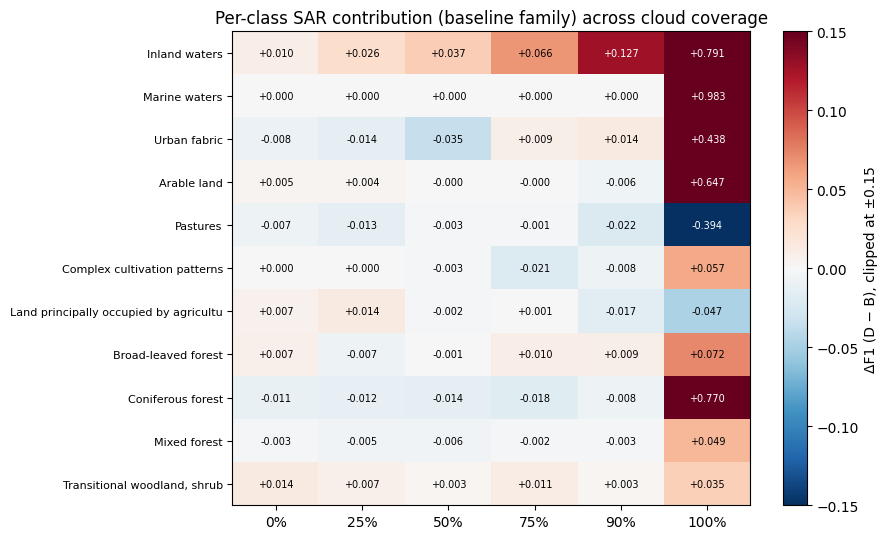

In [20]:
GROUPS = {
    'Water':  ['Inland waters', 'Marine waters'],
    'Urban':  ['Urban fabric'],
    'Agriculture': ['Arable land', 'Pastures', 'Complex cultivation patterns',
                    'Land principally occupied by agriculture, with significant areas of natural vegetation'],
    'Forest & shrub': ['Broad-leaved forest', 'Coniferous forest', 'Mixed forest',
                       'Transitional woodland, shrub'],
}
assert sorted(sum(GROUPS.values(), [])) == sorted(CLASSES)

def per_class_f1(name, lvl):
    return f1_score(Y[te], probs_cache[(name, lvl)] >= 0.5, average=None, zero_division=0)

delta_mat = pd.DataFrame({f'{lvl:.0%}': per_class_f1('SimpleCNN | D', lvl)
                          - per_class_f1('SimpleCNN | B', lvl)
                          for lvl in MASK_LEVELS},
                         index=[c[:38] for c in CLASSES])
order = sum(GROUPS.values(), [])
delta_mat = delta_mat.loc[[c[:38] for c in order]]
fig, ax = plt.subplots(figsize=(9, 5.5))
im = ax.imshow(np.clip(delta_mat.values, -0.15, 0.15), cmap='RdBu_r', vmin=-0.15, vmax=0.15, aspect='auto')
ax.set_xticks(range(len(MASK_LEVELS)), delta_mat.columns)
ax.set_yticks(range(NC), delta_mat.index, fontsize=8)
for r in range(NC):
    for c_ in range(len(MASK_LEVELS)):
        v = delta_mat.values[r, c_]
        ax.text(c_, r, f'{v:+.3f}', ha='center', va='center', fontsize=7,
                color='white' if abs(v) > 0.09 else 'black')
plt.colorbar(im, label='ΔF1 (D − B), clipped at ±0.15')
ax.set_title('Per-class SAR contribution (baseline family) across cloud coverage')
plt.tight_layout(); plt.savefig(FIG_DIR / 'class_coverage_heatmap.png', dpi=120); plt.show()


,coverage,group,delta_D_minus_B,d_lo,d_hi,significant
0,0.00,Water,0.0050,-0.0062,0.0161,False
1,0.00,Urban,-0.0087,-0.0466,0.0277,False
2,0.00,Agriculture,0.0011,-0.0059,0.0080,False
3,0.00,Forest & shrub,0.0016,-0.0044,0.0080,False
4,0.25,Water,0.0131,0.0023,0.0246,True
5,0.25,Urban,-0.0144,-0.0505,0.0204,False
6,0.25,Agriculture,0.0016,-0.0054,0.0083,False
7,0.25,Forest & shrub,-0.0044,-0.0105,0.0016,False
8,0.50,Water,0.0183,0.0065,0.0304,True
9,0.50,Urban,-0.0353,-0.0743,-0.0010,True


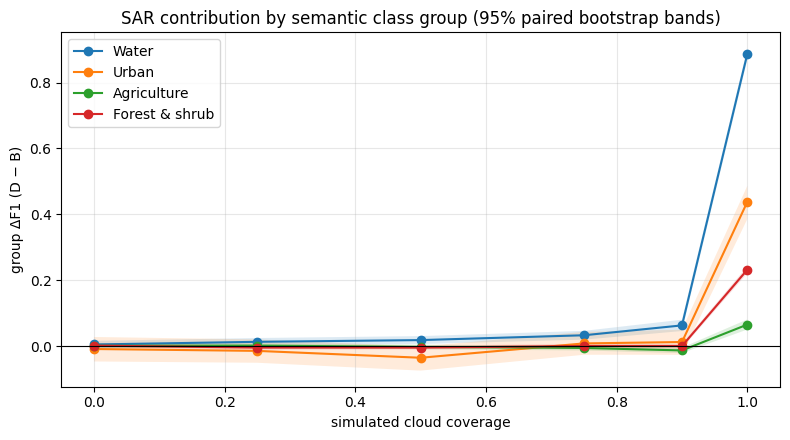

In [21]:
grows = []
for lvl in MASK_LEVELS:
    predB = probs_cache[('SimpleCNN | B', lvl)] >= 0.5
    predD = probs_cache[('SimpleCNN | D', lvl)] >= 0.5
    for g, cs in GROUPS.items():
        cidx = [CLASSES.index(c) for c in cs]
        d = boot_macro_f1(predD, cols=cidx) - boot_macro_f1(predB, cols=cidx)
        grows.append({'coverage': lvl, 'group': g, 'delta_D_minus_B': d.mean(),
                      'd_lo': np.percentile(d, 2.5), 'd_hi': np.percentile(d, 97.5),
                      'significant': bool(np.percentile(d, 2.5) > 0 or np.percentile(d, 97.5) < 0)})
gci = pd.DataFrame(grows)
display(gci.round(4)); gci.to_csv(PROC_DIR / 'group_deltas.csv', index=False)

fig, ax = plt.subplots(figsize=(8, 4.5))
for g in GROUPS:
    s = gci[gci['group'] == g]
    ax.plot(s['coverage'], s['delta_D_minus_B'], marker='o', label=g)
    ax.fill_between(s['coverage'], s['d_lo'], s['d_hi'], alpha=.15)
ax.axhline(0, color='k', lw=.8); ax.set_xlabel('simulated cloud coverage')
ax.set_ylabel('group ΔF1 (D − B)'); ax.legend(); ax.grid(alpha=.3)
ax.set_title('SAR contribution by semantic class group (95% paired bootstrap bands)')
plt.tight_layout(); plt.savefig(FIG_DIR / 'group_deltas.png', dpi=120); plt.show()


### Exploiting the pattern — selective per-class fusion (model H)

For each class × coverage level, use the baseline family's D probability if D beats B on the
**validation** split, else B's. Selection never sees test data.


In [22]:
va = split_idx['validation']
hyb_rows, hyb_probs = [], {}
for li, lvl in enumerate(tqdm(MASK_LEVELS, desc='selective fusion')):
    spec = li if lvl > 0 else None
    f1vB = f1_score(Y[va], predict(model_B, va, spec, False) >= .5, average=None, zero_division=0)
    f1vD = f1_score(Y[va], predict(model_D, va, spec, True) >= .5, average=None, zero_division=0)
    use_D = f1vD > f1vB
    pt = probs_cache[('SimpleCNN | B', lvl)].copy()
    pt[:, use_D] = probs_cache[('SimpleCNN | D', lvl)][:, use_D]
    hyb_probs[lvl] = pt
    hyb_rows.append({'coverage': lvl, 'n_from_D': int(use_D.sum()),
                     'classes_from_D': ', '.join(np.array(CLASSES)[use_D]) or '-',
                     'H_macro_F1': macro_f1(Y[te], pt),
                     'B_macro_F1': macro_f1(Y[te], probs_cache[('SimpleCNN | B', lvl)]),
                     'D_macro_F1': macro_f1(Y[te], probs_cache[('SimpleCNN | D', lvl)])})
hyb = pd.DataFrame(hyb_rows)
display(hyb[['coverage', 'n_from_D', 'B_macro_F1', 'D_macro_F1', 'H_macro_F1']].round(4))

hrows = []
for lvl in MASK_LEVELS:
    bH = boot_macro_f1(hyb_probs[lvl] >= 0.5)
    for other in ['B', 'D']:
        d = bH - boot[(f'SimpleCNN | {other}', lvl)]
        hrows.append({'coverage': lvl, 'vs': other, 'delta_H': d.mean(),
                      'd_lo': np.percentile(d, 2.5), 'd_hi': np.percentile(d, 97.5),
                      'significant': bool(np.percentile(d, 2.5) > 0 or np.percentile(d, 97.5) < 0)})
hci = pd.DataFrame(hrows)
display(hci.round(4)); hci.to_csv(PROC_DIR / 'hybrid_deltas.csv', index=False)


selective fusion:   0%|          | 0/6 [00:00<?, ?it/s]

selective fusion:  17%|█▋        | 1/6 [00:27<02:16, 27.27s/it]

selective fusion:  33%|███▎      | 2/6 [00:57<01:57, 29.28s/it]

selective fusion:  50%|█████     | 3/6 [01:27<01:28, 29.51s/it]

selective fusion:  67%|██████▋   | 4/6 [01:57<00:59, 29.56s/it]

selective fusion:  83%|████████▎ | 5/6 [02:27<00:29, 29.93s/it]

selective fusion: 100%|██████████| 6/6 [02:40<00:00, 24.12s/it]

selective fusion: 100%|██████████| 6/6 [02:40<00:00, 26.80s/it]

,coverage,n_from_D,B_macro_F1,D_macro_F1,H_macro_F1
0,0.00,6,0.7495,0.7507,0.7515
1,0.25,6,0.7461,0.7461,0.7449
2,0.50,5,0.7465,0.7443,0.7464
3,0.75,6,0.7301,0.7350,0.7379
4,0.90,7,0.7144,0.7225,0.7262
5,1.00,10,0.3295,0.6388,0.6746


,coverage,vs,delta_H,d_lo,d_hi,significant
0,0.00,B,0.0019,-0.0027,0.0066,False
1,0.00,D,0.0008,-0.0012,0.0030,False
2,0.25,B,-0.0012,-0.0056,0.0028,False
3,0.25,D,-0.0012,-0.0040,0.0015,False
4,0.50,B,-0.0002,-0.0047,0.0039,False
5,0.50,D,0.0021,-0.0004,0.0046,False
6,0.75,B,0.0078,0.0030,0.0125,True
7,0.75,D,0.0029,0.0003,0.0058,True
8,0.90,B,0.0116,0.0064,0.0168,True
9,0.90,D,0.0037,0.0012,0.0061,True


### Representative successes and failures (75% coverage)

Best SAR-assisted model overall vs the best optical-only model at 75% coverage.


best SAR model @75%: VGG11 | D (0.7407) | best optical: SimpleCNN | B (0.7301)
exact-match at 75%: optical 11.1%, SAR-assisted 12.6% | rescued: 81 | both fail: 1831


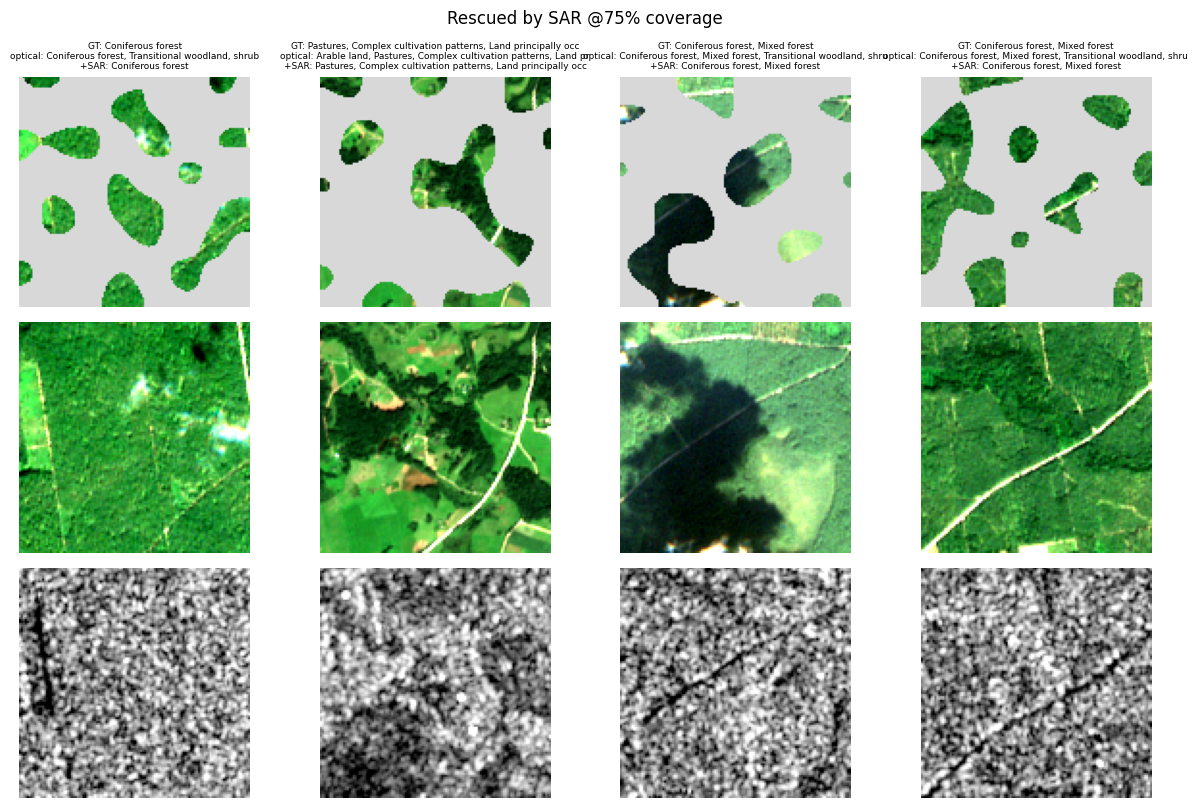

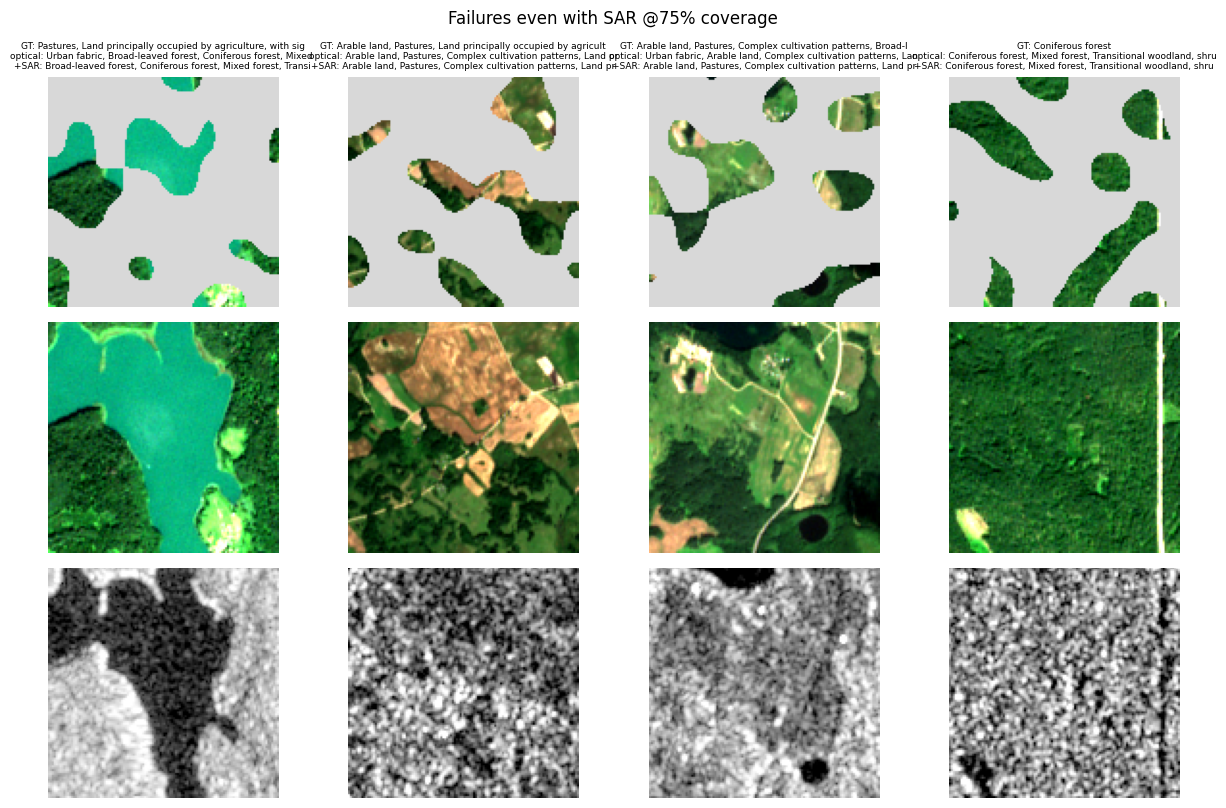

In [23]:
LEVEL75_COV = 0.75
sar_names = [n for n, _, u in EVALS if u]
opt_names = [n for n, _, u in EVALS if not u and n != 'A | SimpleCNN clean-trained']
r75 = res[res['coverage'] == LEVEL75_COV].set_index('model')['macro_F1']
best_sar = r75[sar_names].idxmax(); best_opt = r75[opt_names].idxmax()
print(f'best SAR model @75%: {best_sar} ({r75[best_sar]:.4f}) | best optical: {best_opt} ({r75[best_opt]:.4f})')
pS, pB75 = probs_cache[(best_sar, LEVEL75_COV)], probs_cache[(best_opt, LEVEL75_COV)]
ys_hat, yb_hat = pS >= 0.5, pB75 >= 0.5
yt_b = Y[te].astype(bool)
exactB, exactS = (yb_hat == yt_b).all(1), (ys_hat == yt_b).all(1)
rescued   = np.where(exactS & ~exactB)[0]
both_fail = np.where(~exactS & ~exactB)[0]
print(f'exact-match at 75%: optical {exactB.mean():.1%}, SAR-assisted {exactS.mean():.1%} | '
      f'rescued: {len(rescued)} | both fail: {len(both_fail)}')
LEVEL75 = MASK_LEVELS.index(LEVEL75_COV)

def show_cases(case_ids, title, n=4):
    rng = np.random.default_rng(SEED)
    pick = rng.choice(case_ids, min(n, len(case_ids)), replace=False)
    fig, axes = plt.subplots(3, len(pick), figsize=(3.1 * len(pick), 8.2))
    axes = axes.reshape(3, -1)
    for j, k in enumerate(pick):
        gi = te[k]; m = eval_mask(LEVEL75, gi)
        im = rgb(gi).copy(); im[m] = 0.85
        axes[0, j].imshow(im); axes[1, j].imshow(rgb(gi)); axes[2, j].imshow(sar_img(gi), cmap='gray')
        fmt = lambda v: ', '.join(np.array(CLASSES)[v] if v.any() else ['-'])[:60]
        axes[0, j].set_title(f'GT: {fmt(yt_b[k])}\noptical: {fmt(yb_hat[k])}\n+SAR: {fmt(ys_hat[k])}', fontsize=6.5)
        for ax in axes[:, j]: ax.axis('off')
    for r, lab in enumerate(['masked S2 (model input)', 'clean S2 (reference)', 'S1 VV']):
        axes[r, 0].set_ylabel(lab, fontsize=8)
    plt.suptitle(title); plt.tight_layout()
    plt.savefig(FIG_DIR / f'{title.split()[0].lower()}_cases.png', dpi=120); plt.show()

if len(rescued):   show_cases(rescued, 'Rescued by SAR @75% coverage')
if len(both_fail): show_cases(both_fail, 'Failures even with SAR @75% coverage')


## 10. Discussion

### Headline: best model per regime (test macro-F1 / label accuracy)

| coverage | best optical-only | best SAR-assisted | SAR gain (same family, sig.?) |
|---|---|---|---|
| 0% | SimpleCNN A — 0.753 / 0.804 | VGG11 C — 0.752 / 0.804 | none needed |
| 50% | SimpleCNN B — 0.747 / 0.795 | VGG11 C — 0.747 / 0.798 | VGG: **+0.7 pts, sig.** |
| 75% | SimpleCNN B — 0.730 / 0.780 | **VGG11 D — 0.741 / 0.796** | VGG: **+1.1 pts, sig.** |
| 90% | SimpleCNN B — 0.714 / 0.767 | **VGG11 D — 0.733 / 0.790** | VGG: **+2.5 pts, sig.** |
| 100% | (all collapse, ≤0.33) | **SimpleCNN C — 0.711 / 0.762** | +38 pts, sig. |

**Finding 1 — brittleness & recovery (unchanged).** The clean-trained baseline collapses under
masks it never saw (0.753 → 0.41 at 75%); mask augmentation recovers nearly all of it. All
optical-only models collapse at 100% coverage (macro-F1 0–0.33, erratic across seeds), while
SAR-assisted models hold ≈ 0.64–0.71.

**Finding 2 — the mid-coverage SAR benefit is real, it just needed a stronger encoder.**
With SimpleCNN, SAR gains were significant only at ≥90%. The **VGG11 family shows significant
within-family SAR gains at 50% (+0.7), 75% (+0.9–1.1) and 90% (+2.0–2.5 pts)**; the pretrained
family at 75–90%; scratch-ResNet at 90%. VGG11-D is the best model in the entire matrix in the
degraded regime (75–90% coverage), beating even the selective hybrid H (0.741 vs 0.738 at 75%).
Deeper features appear necessary to *integrate* SAR with partial optical rather than merely
fall back on it.

**Finding 3 — early fusion wins at total optical loss in every family.** At 100% coverage,
C ≥ D in all four families (SimpleCNN 0.711 vs 0.639; VGG 0.711 vs 0.551; scratch-ResNet 0.705
vs 0.601; pretrained 0.644 ≈ 0.644). A shared trunk re-purposes its full capacity for SAR when
optical is zeroed; a dedicated SAR branch trains on weaker gradients whenever optical is
visible. Late fusion is (slightly) better at partial coverage, early fusion much better at
total loss — a real design trade-off.

**Finding 4 — no architecture beats the baseline on optical-only; ImageNet transfer fails
here.** Bootstrap table (a): no family's B variant is significantly better than SimpleCNN-B at
any level. Scratch-ResNet is significantly worse at 75–90%; **pretrained ResNet-18 is
significantly worse everywhere (−2 to −3.8 pts)**. ImageNet RGB features transfer poorly to
12-band multispectral 120 px patches (channel-averaged stem init, domain gap, aggressive
stride-4 stem at this resolution) — consistent with the remote-sensing literature that favours
domain-specific pretraining (SSL4EO, BigEarthNet-pretrained) over ImageNet. Interestingly, the
pretrained family still extracts the *largest relative* SAR gains at 90% (+2.6–2.9 pts) —
weak optical features leave SAR more headroom.

**Finding 5 — class-conditional SAR value (baseline family; replicates earlier runs).**
Water: significantly positive at every coverage ≥25%, monotonically growing (+1.4 → +6.3 pts,
+89 at 100%). Agriculture: significantly negative at 90%. Urban: positive but underpowered
(265 test positives). The selective per-class hybrid H beats both of its parents significantly
at 75–100% — though the VGG11 family now shows that a stronger *learned* fusion captures more
than post-hoc selection.

**Finding 6 — seed replicates (baseline family).** SAR deltas positive 9/9 (model × seed) at
75% and 90% coverage; ≤50% deltas seed-consistently ≈ 0 or slightly negative. Training noise
(~±0.5–1 pt) cannot explain the VGG mid-coverage gains (+0.7…+2.5) — though replicating seeds
for the VGG family is the obvious next robustness check.

**On the accuracy metrics.** Label accuracy (per-label binary accuracy) tracks macro-F1's
ordering: e.g. at 75% coverage VGG11-D classifies 79.6% of all label decisions correctly vs
78.0% for the best optical-only model; subset accuracy (all 11 labels exactly right) is ~11–12%
for the best models at 75% — the strictest view of the same gap. Note the ~68% all-negative
base rate of label accuracy; macro-F1 remains the primary metric.

### Threats to validity we controlled for
- **Paired everything**: identical deterministic masks per patch across all 13 models, seeds
  and levels; bootstrap deltas on shared resamples; seed replicates vary training only.
- **No leakage**: official reBEN splits; train-only normalisation stats; H's selection on
  validation; fixed 0.5 thresholds; single fixed fine-tuning LR (not tuned).
- **Multiple comparisons**: 90 bootstrap tests → ~4–5 expected false positives at 95%; we rely
  only on effects consistent across levels, families, or seeds (e.g. VGG SAR gains significant
  at three consecutive levels; early-fusion-wins-at-100% replicated 4/4 families).

### Known limitations
- Simulated masks (band-mean fill) approximate thick clouds; thin cloud/haze/shadows corrupt
  rather than remove signal.
- Scene-level noisy CORINE labels; single country/season; Urban conclusions rest on 265 test
  positives.
- VGG results come from one seed; its mid-coverage SAR gains exceed observed seed noise but
  replicates would firm them up.

### What I would try next
1. **Seed replicates for the VGG11 family** — confirm the strongest new result.
2. **Domain pretraining** (SSL4EO / BigEarthNet-pretrained backbones) instead of ImageNet.
3. **Mask as explicit input channel**; **learned gating** to combine early-fusion robustness
   at total loss with late-fusion mid-coverage strength.
4. **Real cloud degradation** (overlay genuinely cloudy Sentinel-2 acquisitions).
5. Scale to the full 19-class reBEN dataset across countries/seasons.
